<h1 style="text-align: center; color: lightgreen; font-size: 36px; font-weight: bold;">
    🦠 Colon Cancer Detection Using CNN 🦠
</h1>
<hr style="height: 2px; border: none; background-color: lightgreen;">


<h1 style="color: ORANGE; font-size: 32px; font-weight: bold;">
    🏥 1. Introduction
</h1>
<p><strong>🩺 Goal:</strong></p>
<p>This project aims to develop an AI-driven approach for **colon cancer detection** by classifying histopathological images of colon tissue. Early and accurate detection of colon cancer is critical for effective treatment and improved survival rates. By leveraging deep learning techniques, we seek to enhance the diagnostic process and assist medical professionals in identifying malignant tissue with greater precision.</p>  

<p>In this study, we implement two deep learning approaches:</p>
<ul>
    <li>🧬 A custom Convolutional Neural Network (CNN) model trained from scratch</li>
    <li>🖥️ A Transfer Learning approach using pretrained models such EfficientNet</li>
</ul>  

<p>By comparing both models, we aim to determine the most effective approach for classifying histopathological images of lung and colon tissue.</p>

<h2 style="color: lightpink; font-weight: bold;"> 🏨 Medical Context:</h2>
  
<p>🩸 <strong>Colon Cancer</strong> ialso known as colorectal cancer (CRC), is one of the most prevalent and life-threatening cancers worldwide. It originates in the **colon or rectum, often developing from benign polyps that become malignant over time. Early detection through histopathological analysis is essential for improving treatment outcomes. </p>

<h3 style="color: #68D2E8; font-weight: bold;"> 🔬 Histopathology Overview:</h3>
<ul>
    <li>🧫 Benign tissue** – Healthy, normal cellular structures.</li>
    <li>🦠 Malignant tissue (Adenocarcinoma)** – Abnormal cell morphology, increased mitotic activity, and disrupted architecture. </li>  
</ul>

<h3 style="color: #68D2E8; font-weight: bold;"> 🏥 Types of Colon Cancer in the Dataset </h3> 
<ul>
    <li>🦠 Colon Adenocarcinoma** – The most common form of colon cancer, originating from glandular cells in the colon lining. </li> 
    <li> Colon Benign Tissue** – Normal, non-cancerous tissue used for comparison in classification tasks.  </li>
</ul>

<h2 style="color: lightpink; font-weight: bold;"> ⚕️ Key Steps:</h2>
<ul>
    <li>🩻 <strong>Data Understanding</strong> – Exploring the dataset structure and distribution.</li>
    <li>🧪 <strong>Data Exploration & Visualization</strong> – Examining sample images and their histopathological characteristics.</li>
    <li>🧼 <strong>Data Preprocessing</strong> – Image resizing, normalization, and augmentation.</li>
    <li>⚖️ <strong>Handling Class Imbalance</strong> – Ensuring balanced training samples.</li>
    <li>🧠 <strong>Modeling (Custom CNN)</strong> – Designing and training a CNN from scratch.</li>
    <li>🦾 <strong>Transfer Learning</strong> – Fine-tuning a pretrained model for classification.</li>
    <li>📉 <strong>Model Evaluation & Comparison</strong> – Analyzing performance metrics and determining the best approach.</li>
</ul>
<h2 style="color: lightpink; font-weight: bold;"> 🧬 Models Used:</h2>
<ul>
    <li>🩻 Custom CNN Model</li>
    <li>🧠 Transfer Learning with Pretrained Models (e.g., VGG16, ResNet, EfficientNet)</li>
</ul>
## 🏷️ Dataset  
This dataset consists of **histopathological images** of **colon tissue** categorized into **benign and malignant samples**. The images undergo augmentation to enhance diversity and improve model robustness.  

<h2 style="color: lightpink; font-weight: bold;"> 🏷️ Dataset:</h2>
<p>This dataset contains <strong>10,000 histopathological images</strong> across <strong>two classes</strong>, with each class containing 5,000 images.</p>

<h3 style="color: #68D2E8; font-weight: bold;"> 🗂️ Dataset Composition:</h3>
<ul>
    <li>🦠 <strong>Colon Adenocarcinoma</strong> (5,000 images)</li>
    <li>🦠 <strong>Colon Benign Tissue</strong> (5,000 images)</li>
</ul>

<p>The original dataset consisted of <strong>500 colon tissue images</strong> (250 benign, 250 adenocarcinoma). These were augmented to <strong>10,000 images</strong> using the Augmentor package.</p>

<h2 style="color: lightpink;"> 📊 Evaluation Metrics:</h2>
<ul>
    <li>📈 <strong>Accuracy</strong> – Measures the overall correctness of the model.</li>
    <li>🎯 <strong>Precision</strong> – Determines the proportion of true positive predictions.</li>
    <li>🔄 <strong>Recall</strong> – Evaluates how well the model identifies actual cancer cases.</li>
    <li>📊 <strong>F1-score</strong> – Balances precision and recall for a comprehensive performance measure.</li>
    <li>🧪 <strong>ROC-AUC</strong> – Analyzes the trade-off between sensitivity and specificity.</li>
</ul>

<p>By implementing this study, we aim to enhance automated medical image classification, assisting pathologists in making faster and more accurate cancer diagnoses.</p>


# **Import needed libraries**

In [1]:
# import system libs
import os
import itertools

# import data handling tools
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB3

# ignore the warnings
import warnings
warnings.filterwarnings('ignore')

2024-04-05 15:18:27.081219: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-05 15:18:27.081311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-05 15:18:27.215876: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Loading the dataset**

> Read the training dataset into the dataframe

In [2]:
# loading the dataset
def loading_the_data(data_dir):
    # Generate data paths with labels
    filepaths = []
    labels = []

    # Get folder names
    folds = os.listdir(data_dir)

    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            
            filepaths.append(fpath)
            labels.append(fold)

    # Concatenate data paths with labels into one DataFrame
    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')

    df = pd.concat([Fseries, Lseries], axis=1)
    
    return df


# change label names to its original names
def change_label_names(df, column_name):
    index = {'colon_aca': 'Colon_adenocarcinoma', 'colon_n': 'Colon_benign_tissue'}


    df[column_name] = df[column_name].replace(index)

In [3]:
# loading the data
data_dir = '/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets'
df = loading_the_data(data_dir)

change_label_names(df, 'labels')

df

,filepaths,labels
0,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_adenocarcinoma
1,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_adenocarcinoma
2,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_adenocarcinoma
3,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_adenocarcinoma
4,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_adenocarcinoma
...,...,...
9995,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_benign_tissue
9996,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_benign_tissue
9997,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_benign_tissue
9998,/kaggle/input/lung-and-colon-cancer-histopatho...,Colon_benign_tissue


# **Data preprocessing**

first we will check if the training data is balanced or not

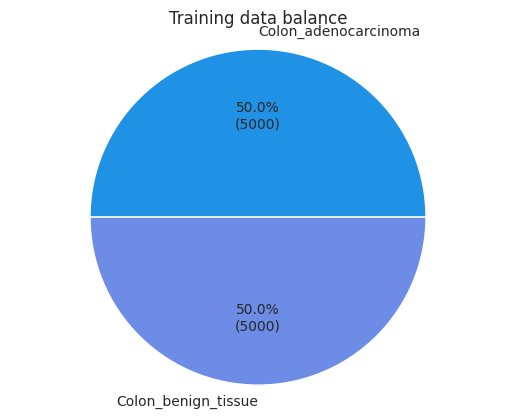

In [4]:
data_balance = df.labels.value_counts()


def custom_autopct(pct):
    total = sum(data_balance)
    val = int(round(pct*total/100.0))
    return "{:.1f}%\n({:d})".format(pct, val)


# pie chart for data balance
plt.pie(data_balance, labels = data_balance.index, autopct=custom_autopct, colors = ["#2092E6","#6D8CE6"])
plt.title("Training data balance")
plt.axis("equal")
plt.show()

It is balanced, now we will split our data to train, val and test set

In [5]:
# data --> 80% train data && 20% (test, val)
train_df, ts_df = train_test_split(df, train_size = 0.8, shuffle = True, random_state = 42)

# test data --> 10% train data && 10% (test, val)
valid_df, test_df = train_test_split(ts_df, train_size = 0.5, shuffle = True, random_state = 42)

**Create image data generator**

in this step we will convert the whoole data to numpy arrays

In [6]:
# crobed image size
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator(rescale=1. / 255)
ts_gen = ImageDataGenerator(rescale=1. / 255)

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 8000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.


**Display sample from train data**

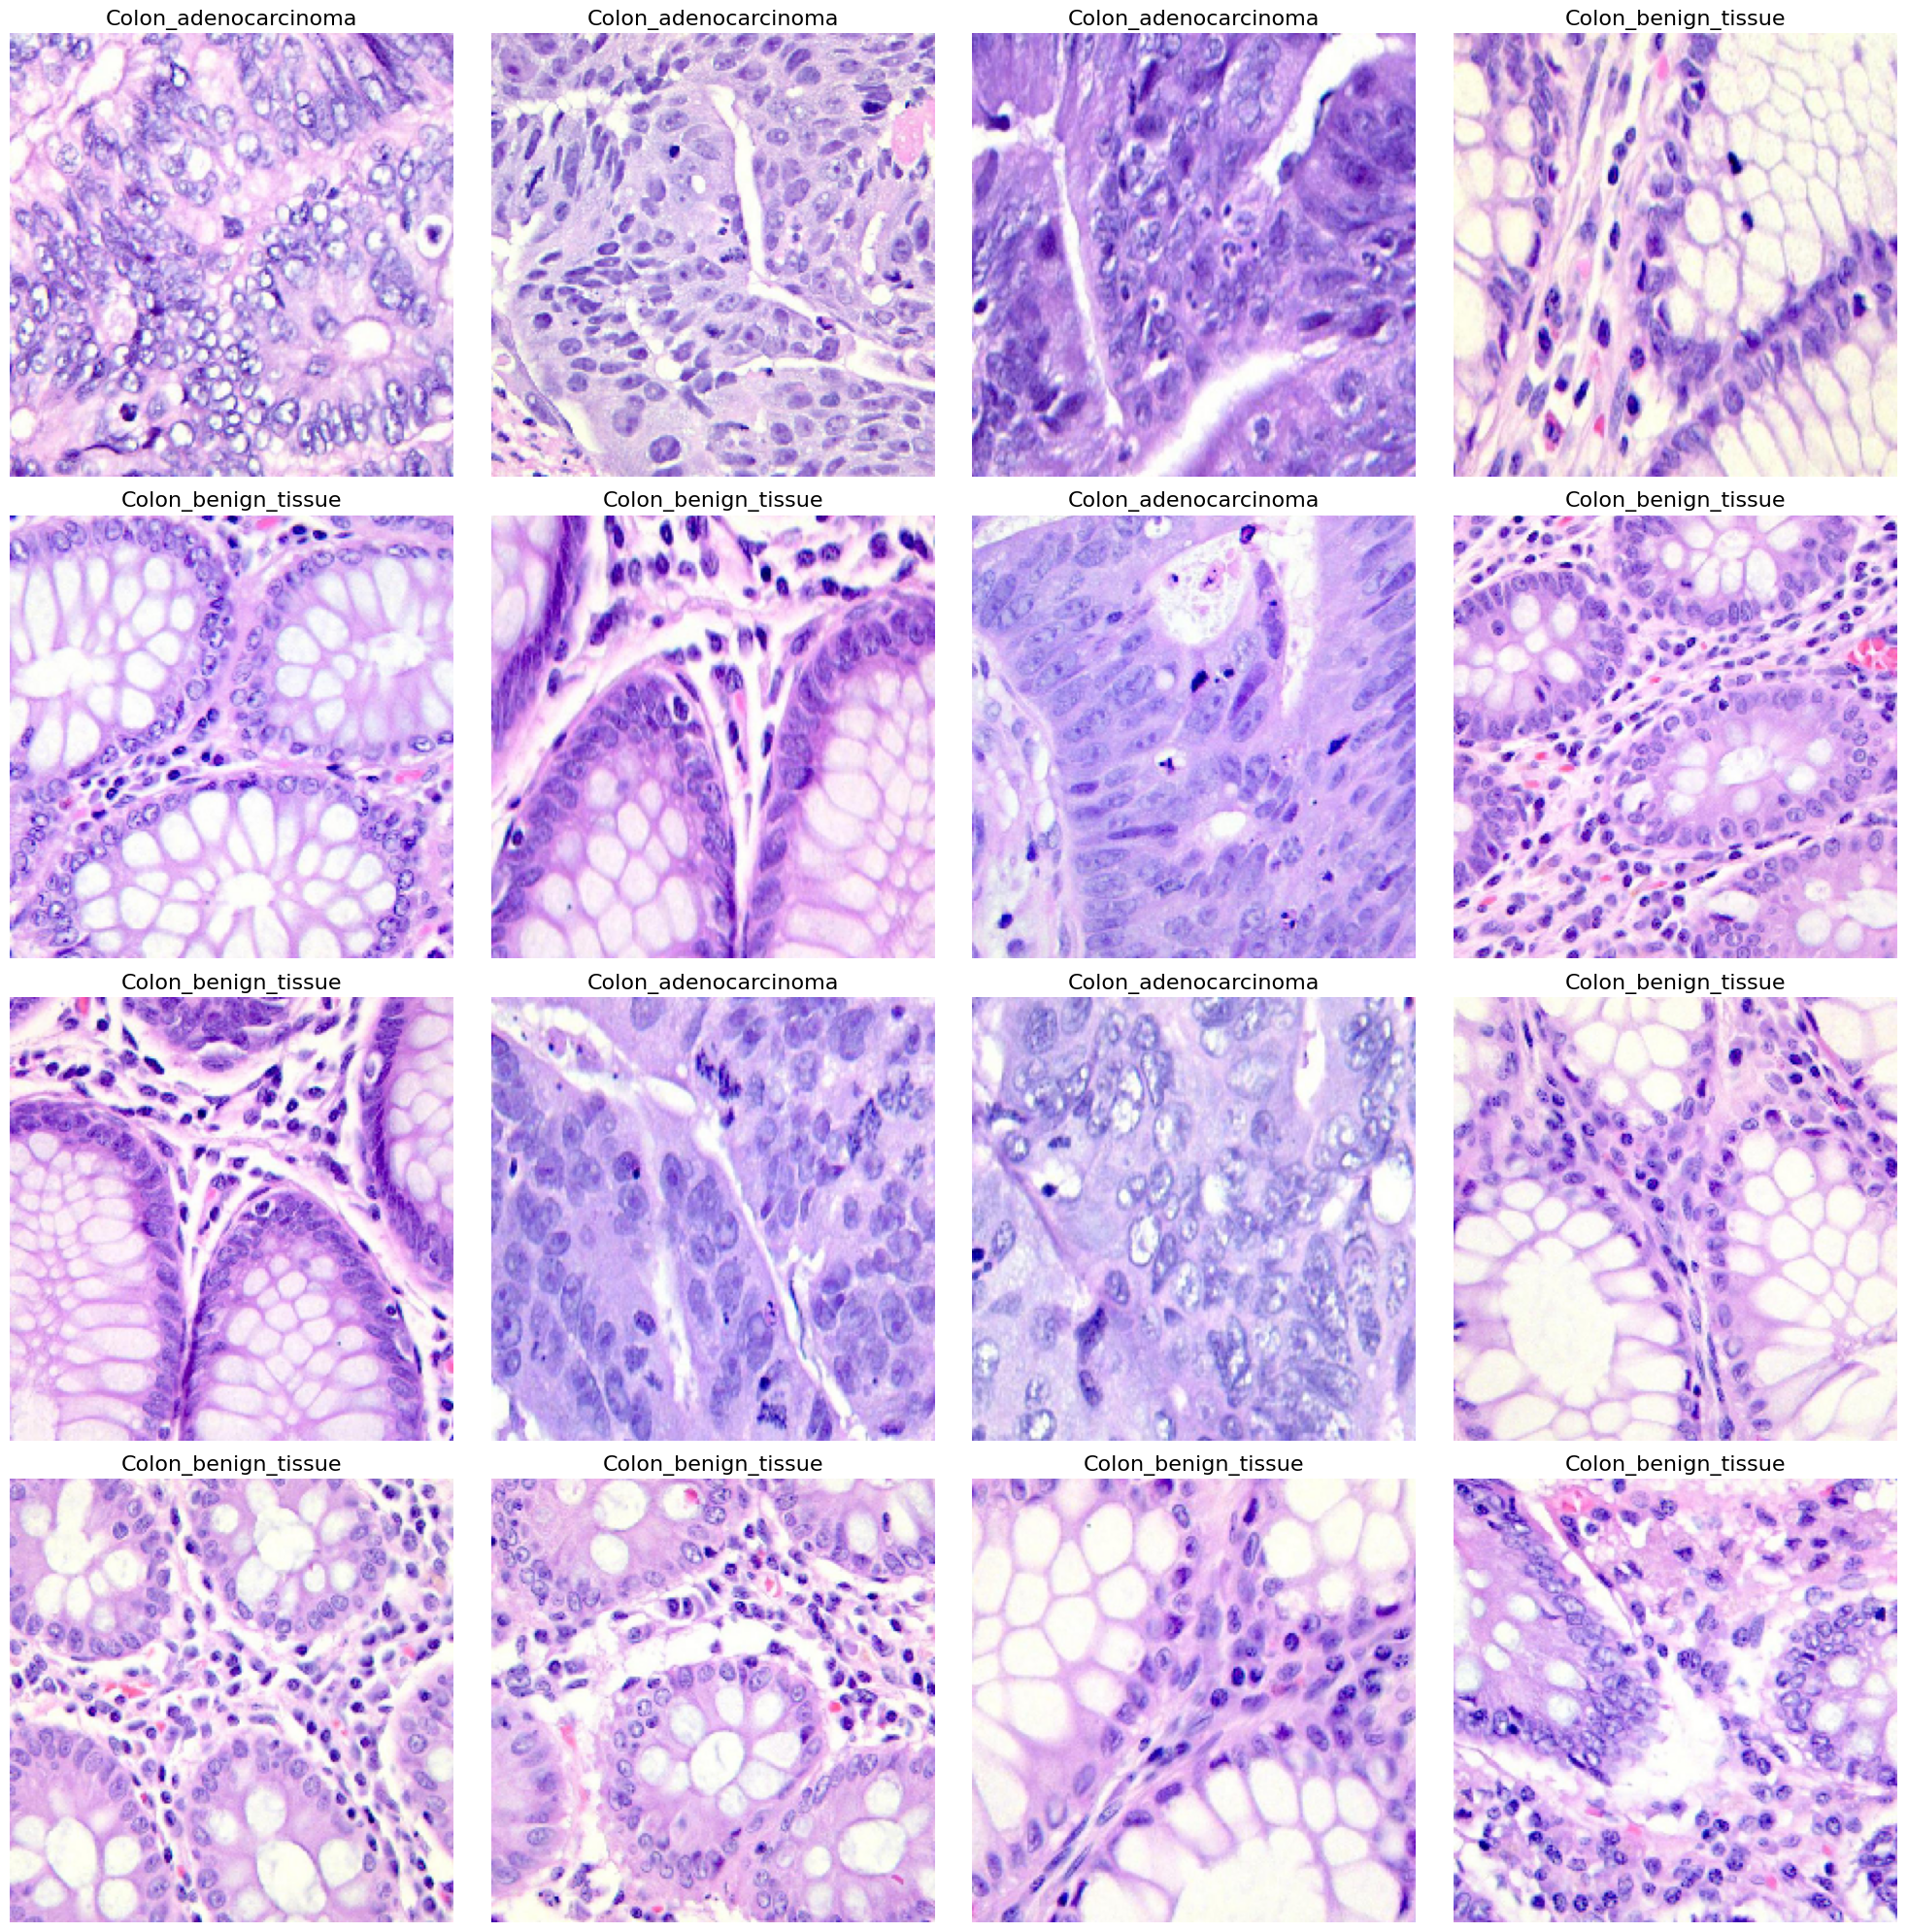

In [7]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

# ploting the patch size samples
plt.figure(figsize= (20, 20))

for i in range(batch_size):
    plt.subplot(4, 4, i + 1)
    image = images[i]
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'black', fontsize= 16)
    plt.axis('off')
plt.tight_layout()
plt.show()

# **Create needed functions**

In [8]:
# Displaying the model performance
def model_performance(history, Epochs):
    # Define needed variables
    tr_acc = history.history['accuracy']
    tr_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    Epochs = [i+1 for i in range(len(tr_acc))]
    
    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')
    
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout
    plt.show()
    

# Evaluate the model
def model_evaluation(model):
    train_score = model.evaluate(train_gen, verbose= 1)
    valid_score = model.evaluate(valid_gen, verbose= 1)
    test_score = model.evaluate(test_gen, verbose= 1)
    
    print("Train Loss: ", train_score[0])
    print("Train Accuracy: ", train_score[1])
    print('-' * 20)
    print("Validation Loss: ", valid_score[0])
    print("Validation Accuracy: ", valid_score[1])
    print('-' * 20)
    print("Test Loss: ", test_score[0])
    print("Test Accuracy: ", test_score[1])
    

# Get Predictions
def get_pred(model, test_gen):
    
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis = 1)
    
    return y_pred


# Confusion Matrix
def plot_confusion_matrix(test_gen, y_pred):
    
    g_dict = test_gen.class_indices
    classes = list(g_dict.keys())
    
    # Display the confusion matrix
    cm = confusion_matrix(test_gen.classes, y_pred)

    plt.figure(figsize= (10, 10))
    plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation= 45)
    plt.yticks(tick_marks, classes)
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')
    
    
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.show()
    
    
# Defining a convolutional NN block for a sequential CNN model
def conv_block(filters, act='relu'):
    
    block = Sequential()
    block.add(Conv2D(filters, 3, activation=act, padding='same'))
    block.add(Conv2D(filters, 3, activation=act, padding='same'))
    block.add(BatchNormalization())
    block.add(MaxPooling2D())
    
    return block


# Defining a dense NN block for a sequential CNN model
def dense_block(units, dropout_rate, act='relu'):
    
    block = Sequential()
    block.add(Dense(units, activation=act))
    block.add(BatchNormalization())
    block.add(Dropout(dropout_rate))
    
    return block

# **Model Structure**

# **CNN model**

In [9]:
# create Model structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_counts = len(list(train_gen.class_indices.keys()))     # to define number of classes in dense layer

In [10]:
# Model architecture
cnn_model = Sequential()

# first conv block
cnn_model.add(Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D())

# second conv block
cnn_model.add(conv_block(32))

# third conv block
cnn_model.add(conv_block(64))

# fourth conv bolck
cnn_model.add(conv_block(128))

# fifth conv block
cnn_model.add(conv_block(256))

# flatten layer
cnn_model.add(Flatten())

# first dense block
cnn_model.add(dense_block(128, 0.5))

# second dense block
cnn_model.add(dense_block(64, 0.3))

# third dense block
cnn_model.add(dense_block(32, 0.2))

# output layer
cnn_model.add(Dense(class_counts, activation = "sigmoid"))

In [11]:
cnn_model.compile(Adamax(learning_rate= 0.001), loss= 'binary_crossentropy', metrics= ['accuracy'])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 56, 56, 32)     │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 64)     │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 14, 14, 128)    │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 7, 7, 256)      │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 128)            │     1,606,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 64)             │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 32)             │         2,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,795,490 (10.66 MB)

 Trainable params: 2,794,050 (10.66 MB)

 Non-trainable params: 1,440 (5.62 KB)

In [12]:
# train the model
epochs = 20   # number of all epochs in training

history = cnn_model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/20
  1/500 ━━━━━━━━━━━━━━━━━━━━ 2:58:49 22s/step - accuracy: 0.3125 - loss: 1.0401

I0000 00:00:1712330371.479656      78 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1712330371.506733      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8037 - loss: 0.4653

W0000 00:00:1712330468.981611      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 225ms/step - accuracy: 0.8039 - loss: 0.4650 - val_accuracy: 0.5420 - val_loss: 1.2747
Epoch 2/20
  1/500 ━━━━━━━━━━━━━━━━━━━━ 1:26 173ms/step - accuracy: 1.0000 - loss: 0.0915

W0000 00:00:1712330483.866440      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9575 - loss: 0.1372 - val_accuracy: 0.9960 - val_loss: 0.0316
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 104ms/step - accuracy: 0.9652 - loss: 0.1090 - val_accuracy: 0.8240 - val_loss: 0.4358
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9748 - loss: 0.0742 - val_accuracy: 0.8450 - val_loss: 0.4461
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - accuracy: 0.9758 - loss: 0.0766 - val_accuracy: 0.9680 - val_loss: 0.0918
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9805 - loss: 0.0595 - val_accuracy: 0.9930 - val_loss: 0.0186
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9823 - loss: 0.0570 - val_accuracy: 0.9900 - val_loss: 0.0278
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 105ms/step - accuracy: 0.9841 - loss: 0.0474 - val_accuracy: 0.9510 - val_loss: 0.1390
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 105ms/step - accuracy: 0.9885 - loss: 0.0363 - val

**Display model performance**

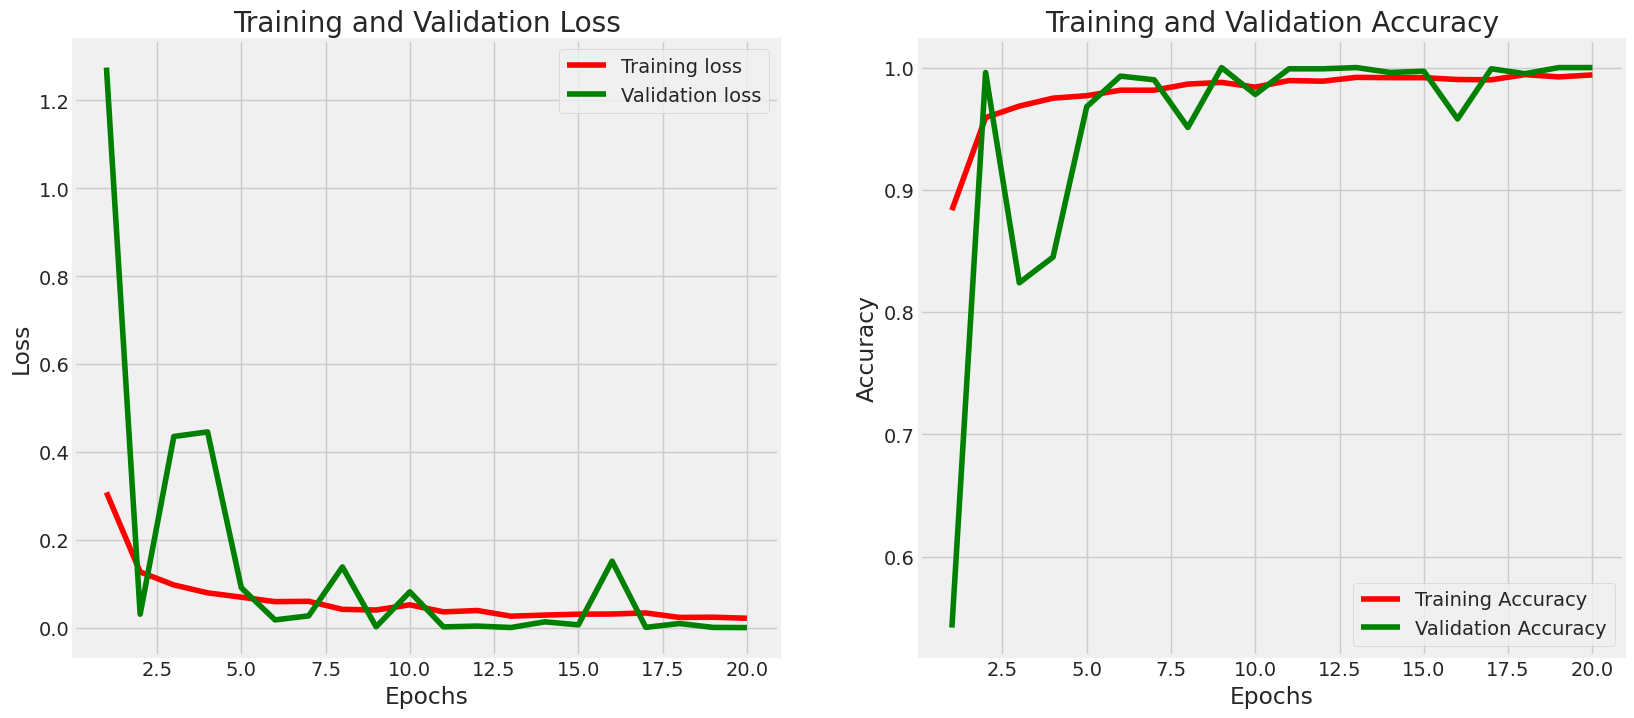

In [13]:
# Display model performance
model_performance(history, epochs)

**Evaluate the model**

In [14]:
# Model evaluation
model_evaluation(cnn_model)

500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 1.0000 - loss: 5.5215e-04
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 1.0000 - loss: 9.7324e-04
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 1.0000 - loss: 5.6066e-04
Train Loss:  0.0005267677479423583
Train Accuracy:  1.0
--------------------
Validation Loss:  0.0010958496714010835
Validation Accuracy:  1.0
--------------------
Test Loss:  0.0005581645527854562
Test Accuracy:  1.0


**Get predictions and display the confusion matrix**

 4/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step

W0000 00:00:1712331464.716268      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step


W0000 00:00:1712331469.730588      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


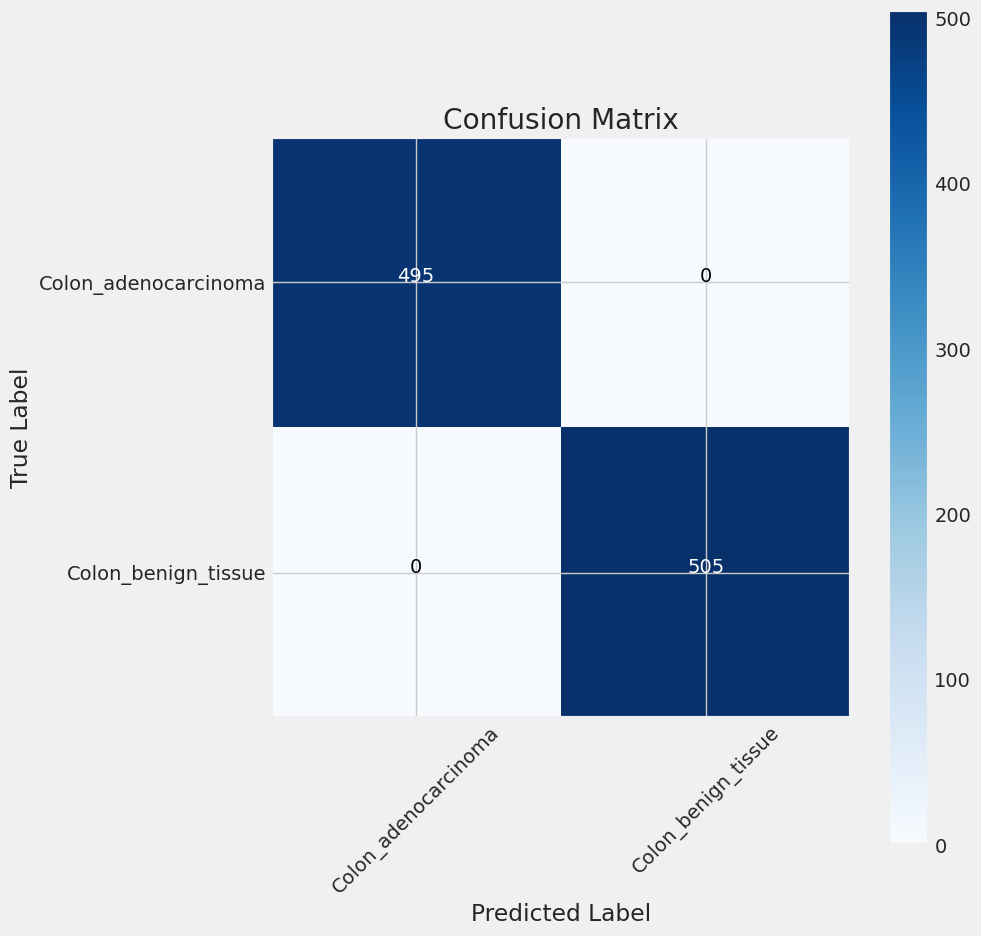

In [15]:
# get predictions
y_pred = get_pred(cnn_model, test_gen)

# plot the confusion matrix
plot_confusion_matrix(test_gen, y_pred)

# **EfficientNetB3**

In [16]:
# get the pre-trained model (EfficientNetB3)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape = img_shape, pooling= None)

# fine-tune EfficientNetB3 (Adding some custom layers on top)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = dense_block(128, 0.5)(x)
x = dense_block(32, 0.2)(x)
predictions = Dense(class_counts, activation = "sigmoid")(x)    # output layer with softmax activation

# the model
EfficientNetB3_model = Model(inputs = base_model.input, outputs = predictions)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
EfficientNetB3_model.compile(optimizer=Adamax(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

EfficientNetB3_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 10,991,249 (41.93 MB)

 Trainable params: 10,900,554 (41.58 MB)

 Non-trainable params: 90,695 (354.28 KB)

In [18]:
# train the model
epochs = 20   # number of all epochs in training

EfficientNetB3_history = EfficientNetB3_model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/20
  1/500 ━━━━━━━━━━━━━━━━━━━━ 22:37:52 163s/step - accuracy: 0.2500 - loss: 1.1682

W0000 00:00:1712331646.340992      79 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8097 - loss: 0.4538

W0000 00:00:1712331728.976312      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 261s 197ms/step - accuracy: 0.8099 - loss: 0.4535 - val_accuracy: 0.5160 - val_loss: 0.7960
Epoch 2/20


W0000 00:00:1712331744.650762      78 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 156ms/step - accuracy: 0.9642 - loss: 0.1442 - val_accuracy: 1.0000 - val_loss: 0.0541
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.9785 - loss: 0.0977 - val_accuracy: 1.0000 - val_loss: 0.0259
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 148ms/step - accuracy: 0.9819 - loss: 0.0791 - val_accuracy: 1.0000 - val_loss: 0.0180
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 147ms/step - accuracy: 0.9868 - loss: 0.0574 - val_accuracy: 1.0000 - val_loss: 0.0143
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 148ms/step - accuracy: 0.9877 - loss: 0.0549 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 147ms/step - accuracy: 0.9934 - loss: 0.0399 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 148ms/step - accuracy: 0.9926 - loss: 0.0410 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 148ms/step - accuracy: 0.9931 - loss: 0.0332 - val

**Display model performance**

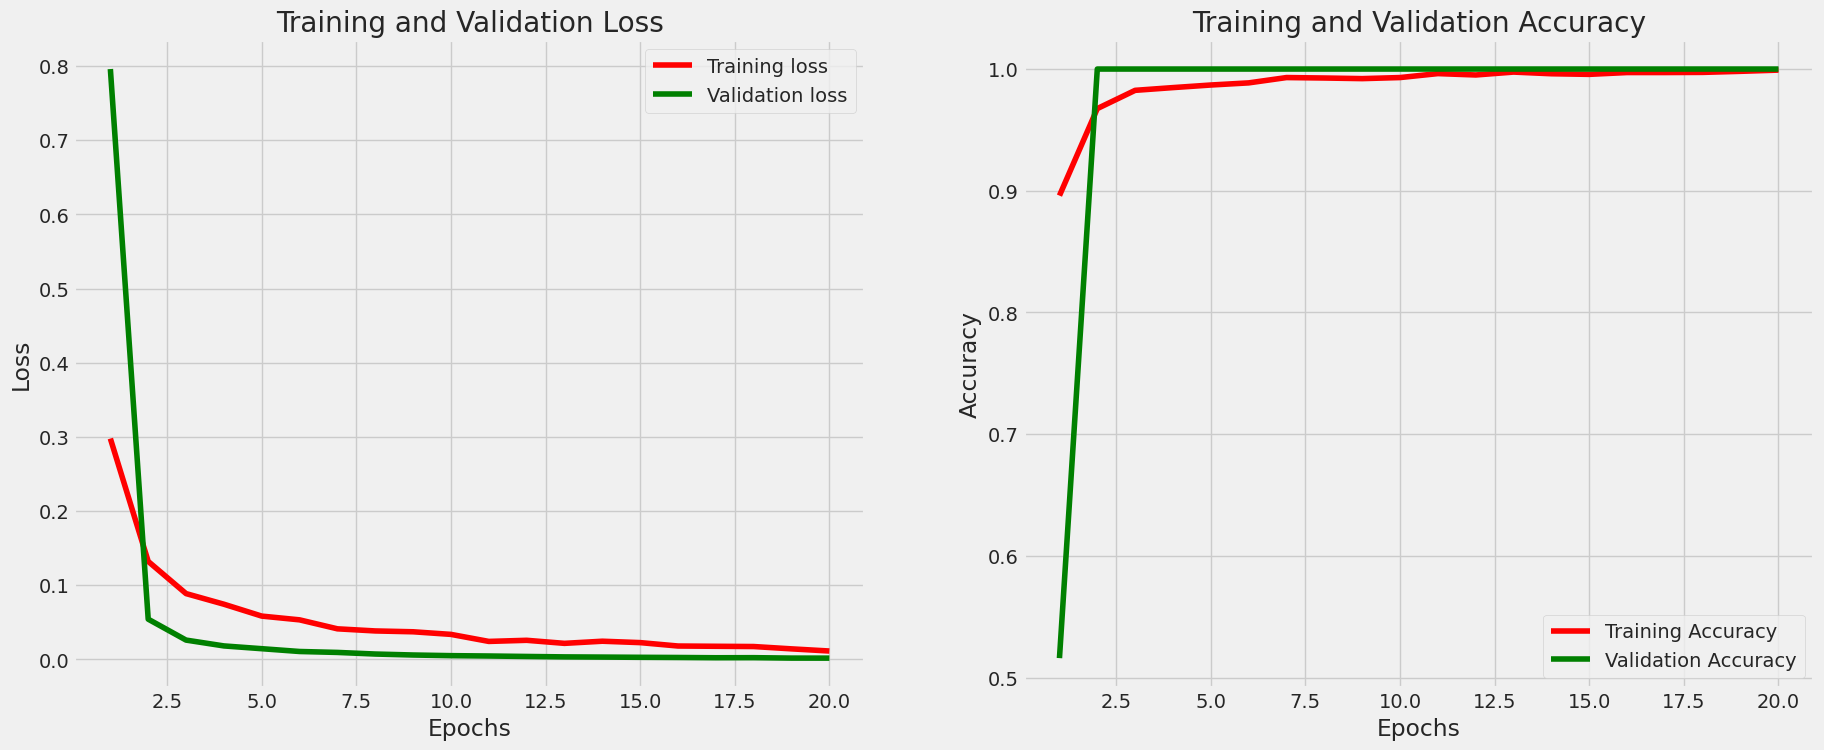

In [19]:
# Display model performance
model_performance(EfficientNetB3_history, epochs)

**Evaluate the model**

In [20]:
# Model evaluation
model_evaluation(EfficientNetB3_model)

500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 1.0000 - loss: 0.0015
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 1.0000 - loss: 0.0015
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 1.0000 - loss: 0.0016
Train Loss:  0.0014661295572295785
Train Accuracy:  1.0
--------------------
Validation Loss:  0.0015560719184577465
Validation Accuracy:  1.0
--------------------
Test Loss:  0.0015882060397416353
Test Accuracy:  1.0


**Get predictions and display the confusion matrix**

 4/63 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step

W0000 00:00:1712333236.666059      79 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step


W0000 00:00:1712333249.906082      77 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


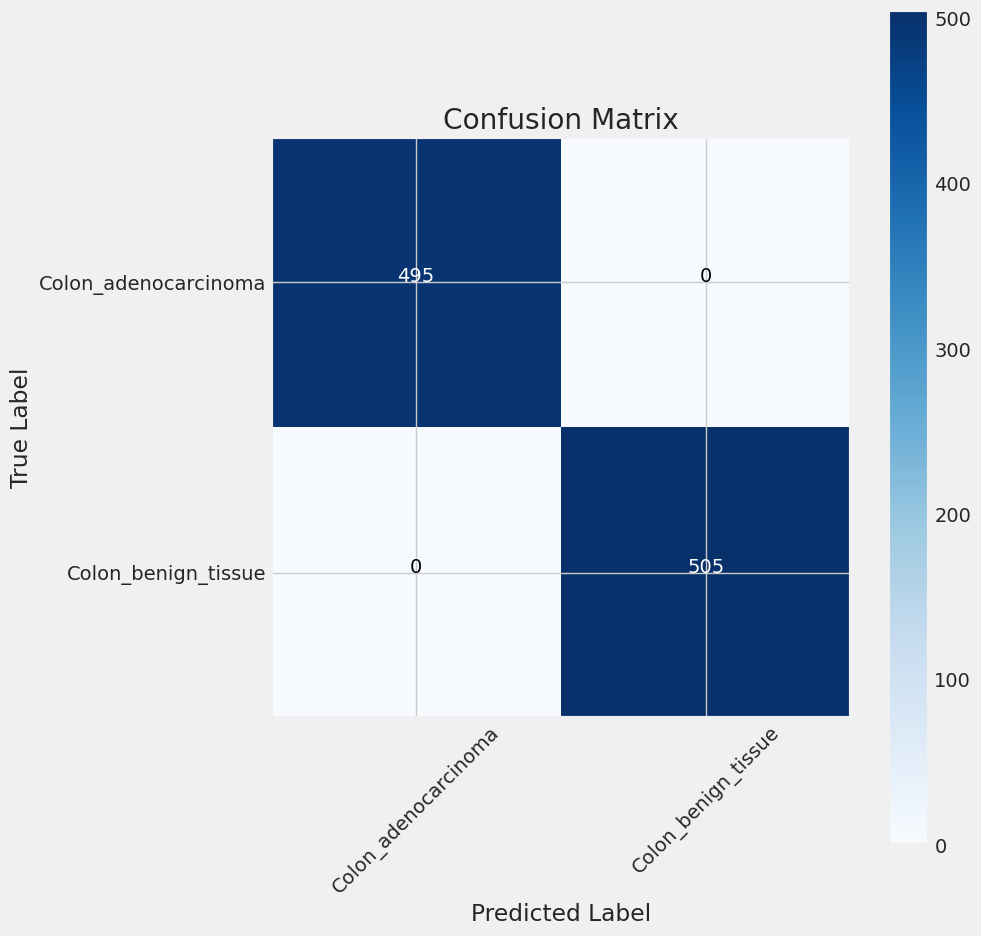

In [21]:
# get predictions
y_pred = get_pred(EfficientNetB3_model, test_gen)

# plot the confusion matrix
plot_confusion_matrix(test_gen, y_pred)